In [6]:
import sys
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

sys.path.append(os.path.dirname(os.getcwd()))
from lib.utils import get_sequence_data
from lib.BLogistic import SkewedBLogistic, train_blogistic
#BLostics

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

folder_path    = r"../../MarketData/historical_data"
context_window = 60
X, Y           = get_sequence_data(folder_path, context_window, force_recompute=True)

dof            = 16
simple_X       = torch.tensor(X[:, :, 0], device=device)
simple_Y       = torch.tensor(Y, device=device).reshape(-1, 1)

dev_size       = 10000
np.random.seed(0)
indices        = np.random.permutation(simple_X.shape[0])

dev_indices   = indices[:dev_size]
train_indices = indices[dev_size:]
train_X       = simple_X[train_indices]
train_Y       = simple_Y[train_indices]
dev_X         = simple_X[dev_indices, :]
dev_Y         = simple_Y[dev_indices]

std     = train_Y.std()
train_X = train_X / std
train_Y = train_Y / std
dev_X   = dev_X / std
dev_Y   = dev_Y / std

print("train_X", train_X.shape,
      "train_Y", train_Y.shape,
      "dev_X",   dev_X.shape,
      "dev_Y",   dev_Y.shape)
print("std", std, train_X.std())

skipping 2020-11-27
skipping 2020-12-24
skipping 2021-11-26
skipping 2022-11-25
skipping 2023-07-03
skipping 2023-11-24
skipping 2024-07-03
skipping 2024-11-29
skipping 2024-12-24
skipping 2025-07-03
train_X torch.Size([402426, 60]) train_Y torch.Size([402426, 1]) dev_X torch.Size([10000, 60]) dev_Y torch.Size([10000, 1])
std tensor(0.0004, device='cuda:0') tensor(1.0232, device='cuda:0')


In [7]:
class CNNProbNN(nn.Module):
    def __init__(self, context_window, dof, device):
        super(CNNProbNN, self).__init__()
        self.context_window = context_window
        self.dof            = dof
        self.device         = device
        self.causal_padding = nn.ConstantPad1d((1, 0), 0.0)

        print(f"\nInitializing CNN with context_window={context_window}, dof={dof}")

        # CNN layers
        self.conv1 = nn.Conv1d(
            in_channels=1,
            out_channels=256,
            kernel_size=2,
            padding=0,
            stride=1
        )

        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.02)
        self.pool    = nn.MaxPool1d(kernel_size=3, stride=3)
        self.flatten = nn.Flatten()

        with torch.no_grad():
            dummy = torch.zeros(1, 1, context_window)
            out = self.causal_padding(dummy)
            out = self.conv1(out)
            out = self.relu(out)
            out = self.dropout(out)
            out = self.pool(out)
            out = self.flatten(out)
            self.flattened_size = int(out.shape[1])

        self.fc = nn.Linear(self.flattened_size, dof)
        nn.init.uniform_(self.fc.weight, -0.01, 0.01)
        nn.init.zeros_(self.fc.bias)

        self.blogistic = SkewedBLogistic(dof - 3, device=device)


    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        x = self.causal_padding(x)
        x = self.relu(self.conv1(x))
        x = self.dropout(x)
        x = self.pool(x)
        x = self.flatten(x)
        params = self.fc(x)
        return params

    def get_params(self, x):
        return self.forward(x)

    def get_logpdf(self, x, sample_xs):
        params = self.get_params(x)
        return self.blogistic.logpdf(sample_xs, params[:, :-2].flatten(),
                                     params[:, -2], params[:, -1])

    def loss_fn(self, x, y):
        params = self.forward(x)
        logpdf = self.blogistic.logpdf_vectorized(
            y, params[:, :-2], params[:, -2], params[:, -1]
        )
        return -logpdf.mean()

    def get_pdf(self, x, sample_xs):
        return torch.exp(self.get_logpdf(x, sample_xs))


In [8]:
def train_cnn_nn(
    train_X, train_Y, dev_X, dev_Y,
    lr, num_steps, device,
    transfer_learn=True,
    batch_size=128
):
    print(f"Train X shape: {train_X.shape}, Train Y shape: {train_Y.shape}")
    print(f"Using batch_size={batch_size}")

    # Initialize model
    model = CNNProbNN(context_window, dof, device).to(device)

    # Optional transfer learning initialization
    if transfer_learn:
        iid_train_steps = 500
        iid_lr = 0.05
        _, offset = train_blogistic(
            train_Y.flatten(), dof, iid_lr, iid_train_steps,
            allow_skew=True, device=device
        )
        with torch.no_grad():
            model.fc.bias[:-2].copy_(offset[0])
            model.fc.bias[-2].copy_(offset[1])
            model.fc.bias[-1].copy_(offset[2])

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=0.002)
    train_losses, dev_losses = [], []

    # Training loop
    for step in range(num_steps):
        model.train()
        running_loss = 0.0
        n_batches = 0

        for i in range(0, train_X.shape[0], batch_size):
            batch_X = train_X[i:i+batch_size]
            batch_Y = train_Y[i:i+batch_size]
            if batch_X.shape[0] == 0:
                continue

            loss = model.loss_fn(batch_X, batch_Y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            n_batches += 1

        avg_train_loss = running_loss / max(n_batches, 1)

        # Periodic validation
        if step % 100 == 0:
            model.eval()
            with torch.no_grad():
                dev_loss_sum = 0.0
                n_dev_batches = 0
                for j in range(0, dev_X.shape[0], batch_size):
                    batch_X = dev_X[j:j+batch_size]
                    batch_Y = dev_Y[j:j+batch_size]
                    if batch_X.shape[0] == 0:
                        continue
                    dev_loss_sum += model.loss_fn(batch_X, batch_Y).item()
                    n_dev_batches += 1
                avg_dev_loss = dev_loss_sum / max(n_dev_batches, 1)


            train_losses.append(avg_train_loss)
            dev_losses.append(avg_dev_loss)
            print(f"[Step {step}] Train Loss: {avg_train_loss:.4f}, Dev Loss: {avg_dev_loss:.4f}")

    print(f"Final Train Loss: {avg_train_loss:.4f}, Final Dev Loss: {avg_dev_loss:.4f}")
    return model, train_losses, dev_losses



In [9]:
print(f"Context window: {context_window}")
print(f"DOF: {dof}")
print(f"Device: {device}")

lr = 2e-4 # cannot use 2e-3 in the paper.
num_steps = 300
model, train_losses, dev_losses = train_cnn_nn(train_X, train_Y, dev_X, dev_Y, lr, num_steps, device=device)

Context window: 60
DOF: 16
Device: cuda
Train X shape: torch.Size([402426, 60]), Train Y shape: torch.Size([402426, 1])
Using batch_size=128

Initializing CNN with context_window=60, dof=16
Step 100, Loss: 1.2566
Step 200, Loss: 1.2521
Step 300, Loss: 1.2504
Step 400, Loss: 1.2499
Step 500, Loss: 1.2498
Step 500, Final Loss: 1.2498
[Step 0] Train Loss: 1.1121, Dev Loss: 1.1139
[Step 100] Train Loss: 1.0917, Dev Loss: 1.1018
[Step 200] Train Loss: 1.0918, Dev Loss: 1.1016
Final Train Loss: 1.0917, Final Dev Loss: 1.1016


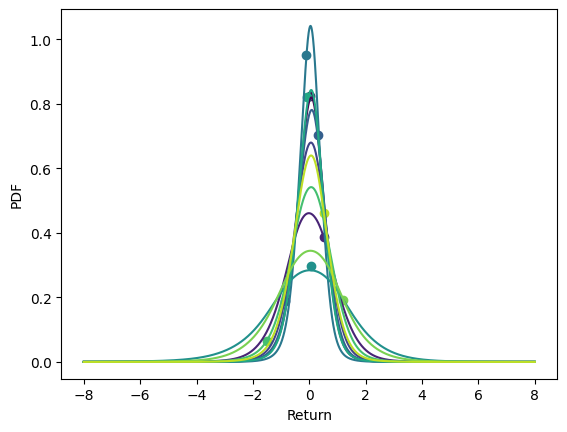

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

plot_xs = torch.linspace(-8, 8, 10000, device=device)
nplots = 10

for idx in range(nplots):
    # get color wheel
    color = plt.cm.viridis(idx / nplots)
    plot_ys = model.get_pdf(dev_X[idx, :].reshape(1, -1), plot_xs)
    plt.plot(plot_xs.cpu().numpy(), plot_ys.detach().cpu().numpy(), color=color)
    plt.scatter(dev_Y[idx, :].cpu().numpy(), model.get_pdf(dev_X[idx, :].reshape(1, -1), dev_Y[idx, :].reshape(1, 1)).detach().cpu().numpy(), color=color)

plt.xlabel("Return")
plt.ylabel("PDF")
plt.show()